### Baseline Random Forests test

### Baseline Random Forests model to establish a non-GNN based benchmark to compare GNN's efficacy in predicting BBBP

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"../data/processed/neuro_natural_dataset.csv")

In [3]:
# feature selection: use only descriptor level features
features = ['mol_wt', 'logp', 'h_donors', 'tpsa', 'qed']

X = df[features]
y = df['permeable'].astype(int)

In [4]:
# train test split with stratification due to 82/12 class imbalance

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
# save the split to a dataframe so GNN can use the same split later

df["split"] = "train"
df.loc[X_test.index, "split"] = "test"
df.to_csv("../data/processed/neuro_natural_dataset.csv", index=False)

In [6]:
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",   # handles the 82/18 imbalance
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=42)

In [7]:
probs = rf.predict_proba(X_test)[:,1]
preds = (probs >= 0.5).astype(int)

print("AUC:", roc_auc_score(y_test, probs))
print("F1:", f1_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("Accuracy:", accuracy_score(y_test, preds))


AUC: 0.882258684784002
F1: 0.9222423146473779
Precision: 0.897887323943662
Recall: 0.9479553903345725
Accuracy: 0.8685015290519877


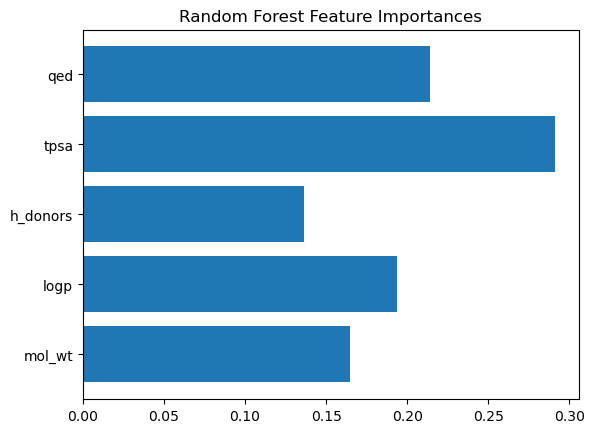

In [8]:
# feature importance plot

importances = rf.feature_importances_
plt.barh(features, importances)
plt.title("Random Forest Feature Importances")
plt.show()


#### Random Forest Feature Importance Analysis

The Random Forest model identifies TPSA, QED, and logP as the dominant drivers of BBB permeability prediction.

- TPSA (0.29) is the most influential feature, reflecting the strong effect of molecular polarity on passive diffusion through the BBB.

- QED (0.25) ranks second, indicating that globally “drug-like” scaffolds are more likely to permeate the CNS.

- logP (0.19) contributes strongly, capturing the hydrophobicity required for BBB penetration.

- Molecular weight (0.16) and H-bond donors (0.12) also play meaningful roles but have weaker influence, as their effects overlap with TPSA and QED.

**These results align precisely with domain knowledge: BBB-permeable molecules tend to be smaller, more lipophilic, and less polar. The feature rankings validate both the dataset and the EDA findings, reinforcing the value of using a graph-based model (GNN) to capture additional structural cues not present in global descriptors.**